In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [3]:
import zipfile
import io

# Assuming the uploaded file is named 'archive (1).zip'
# and its content is in the 'uploaded' dictionary.
zip_filename = 'archive (1).zip'

if zip_filename in uploaded:
    # Write the uploaded zip file content to a file on disk
    with open(zip_filename, 'wb') as f:
        f.write(uploaded[zip_filename])

    # Extract the contents of the zip file
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        print(f'Extracting {zip_filename}...')
        zip_ref.extractall('.') # Extract to the current directory
        print('Extraction complete.')
else:
    print(f'Error: {zip_filename} not found in uploaded files.')


Extracting archive (1).zip...
Extraction complete.


In [4]:
import pandas as pd
df = pd.read_csv('amazon.csv', encoding='unicode_escape')
print(df.shape)
df.head()

(1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,â¹399,"â¹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,â¹199,â¹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,â¹199,"â¹1,899",90%,3.9,"7,928",ã Fast Charger& Data Syncã-With built-in s...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,â¹329,â¹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,â¹154,â¹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print("Libraries loaded!")

Libraries loaded!


In [7]:
df['discounted_price'] = df['discounted_price'].str.replace('â\x82¹','').str.replace(',','').astype(float)
df['actual_price'] = df['actual_price'].str.replace('â\x82¹','').str.replace(',','').astype(float)
df['discount_percentage'] = df['discount_percentage'].str.replace('%','').astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['rating_count'] = df['rating_count'].str.replace(',','').astype(float)
df.dropna(inplace=True)
df['main_category'] = df['category'].apply(lambda x: x.split('|')[0])
print("Cleaned! Shape:", df.shape)

Cleaned! Shape: (1462, 17)


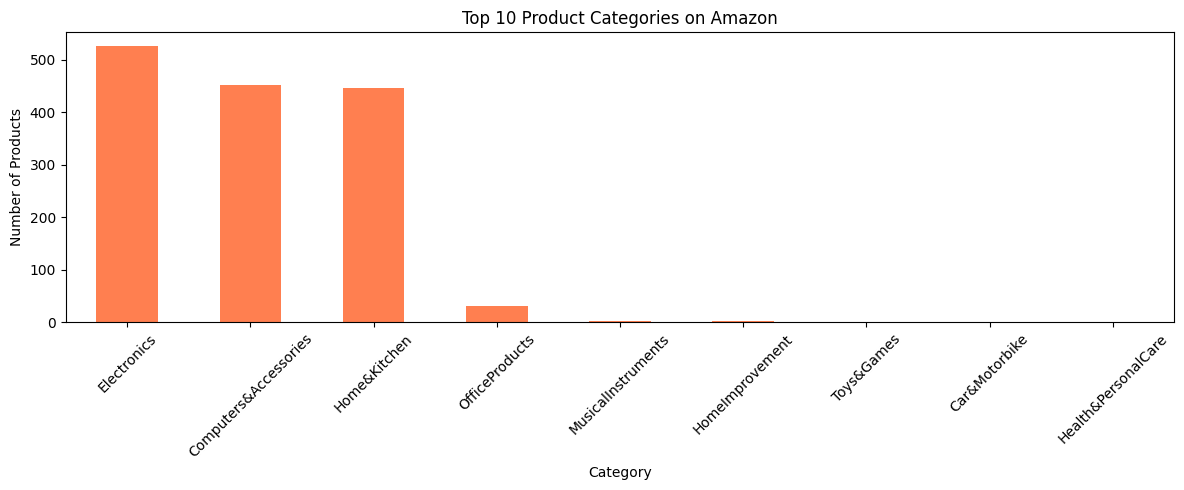

In [8]:
plt.figure(figsize=(12,5))
df['main_category'].value_counts().head(10).plot(kind='bar', color='coral')
plt.title('Top 10 Product Categories on Amazon')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

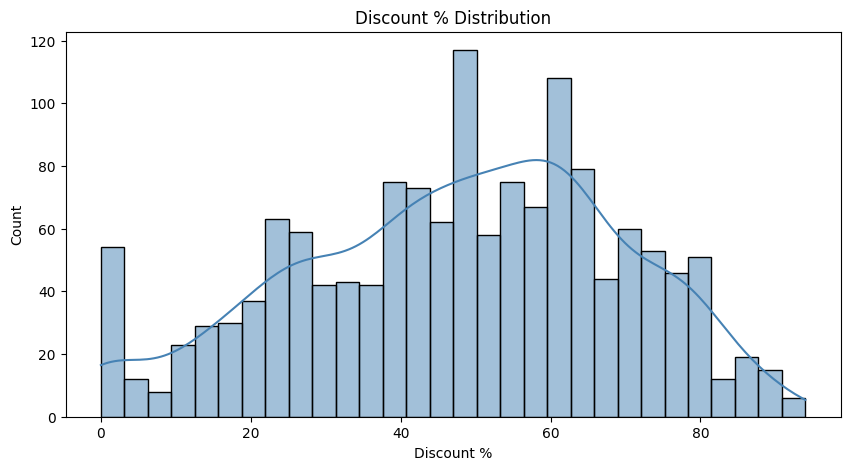

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df['discount_percentage'], bins=30, color='steelblue', kde=True)
plt.title('Discount % Distribution')
plt.xlabel('Discount %')
plt.show()

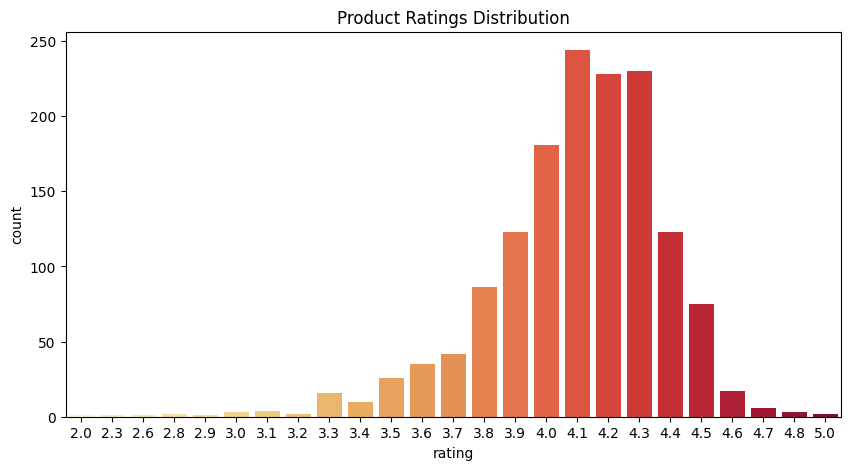

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x='rating', data=df, palette='YlOrRd')
plt.title('Product Ratings Distribution')
plt.show()

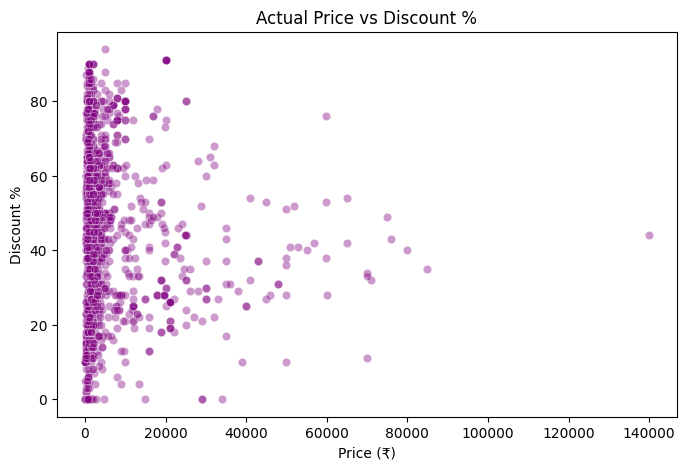

In [11]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='actual_price', y='discount_percentage',
                data=df, alpha=0.4, color='purple')
plt.title('Actual Price vs Discount %')
plt.xlabel('Price (₹)')
plt.ylabel('Discount %')
plt.show()

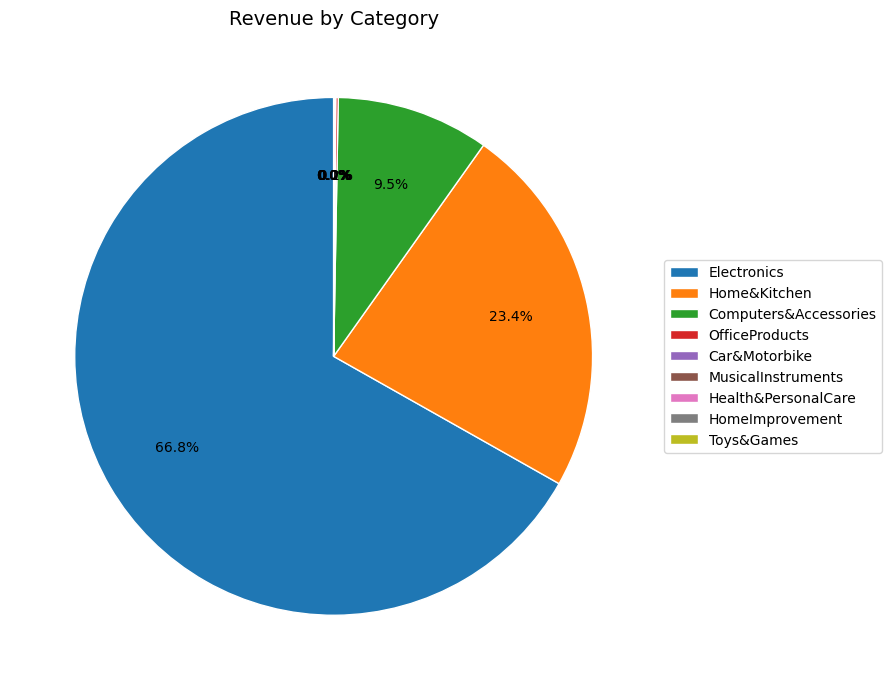

In [23]:
top_cat = (
    df.groupby('main_category')['actual_price']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9,9))

plt.pie(
    top_cat,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.7,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)

plt.legend(
    top_cat.index,
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.title('Revenue by Category', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
print("========== INSIGHTS ==========")
print(f"Total Products   : {len(df)}")
print(f"Avg Discount     : {df['discount_percentage'].mean():.1f}%")
print(f"Avg Rating       : {df['rating'].mean():.2f} ⭐")
print(f"Top Category     : {df['main_category'].value_counts().index[0]}")
print(f"Max Discount     : {df['discount_percentage'].max():.0f}%")
print(f"Avg Price        : ₹{df['actual_price'].mean():.0f}")
print("==============================")

========== INSIGHTS ==========
Total Products   : 1462
Avg Discount     : 47.7%
Avg Rating       : 4.10 ⭐
Top Category     : Electronics
Max Discount     : 94%
Avg Price        : ₹5453
